In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable',
                      noise_model=get_sensitivity,
                      noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                      channels=["A","E"])

In [34]:
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 0.5
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3

Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p=0.0
dev_C_e=0.0


evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e,]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devCp":dev_C_p,
"devCe":dev_C_e}

emri_kwargs = {"T":T, "dt":dt}

should take p0 around for for true waveform:  7.50675326711066
separatrix p:  3.3636344376256564
[0.9, True, False, False, True, 0.0, 0.0]


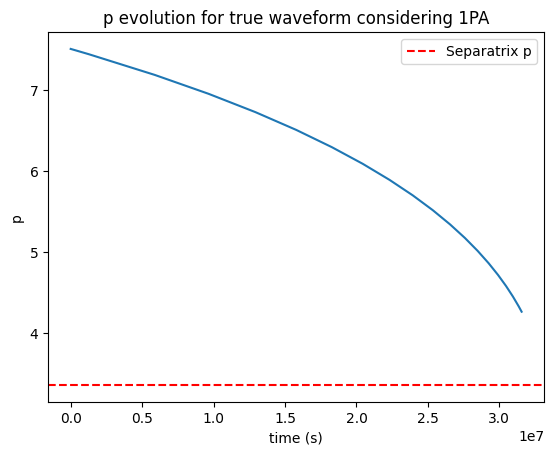

In [ ]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix, 
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]
p_sep = get_separatrix(a, e0, xI0)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
print('should take p0 around for for true waveform: ', p0_should+0.1)
print('separatrix p: ', p_sep)

from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1, m2, a, p0_should+0.1, e0, xI0, *add_args,
                                               Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

In [36]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

# SNR = sef.SNRcalc_SEF(*pars_list,**emri_kwargs,use_gpu=use_gpu)
# print("SNR: ", SNR)
     


Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 7.5, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.9, True, False, False, True, 0.0, 0.0)
Waveform Generated. SNR: 109.44068348468616
calculating stable deltas...
Gamma_ii for m1: 14236.87489695659
Gamma_ii for m1: 14236.875843331984
Gamma_ii for m1: 14236.877620007497
Gamma_ii for m1: 14236.876125621317
Gamma_ii for m1: 14236.875003108526
Gamma_ii for m1: 14236.879430297375
Gamma_ii for m1: 14236.88610519955
Gamma_ii for m1: 14237.092661044006
Gamma_ii for m1: 14236.948961239326
Gamma_ii for m1: 14236.71429135059
Gamma_ii for m1: 14238.83793388457
Gamma_ii for m1: 14236.609330277732
Gamma_ii for m1: 14231.728642002687
Gamma_ii for m1: 14228.596613296793
Gamma_ii for m1: 14238.575494227774
Gamma_ii for m1: 14207.941549380024
[np.float64(6.647353004023656e-08), np.float64(1.2479390221870082e-07), np.float64(1.0496

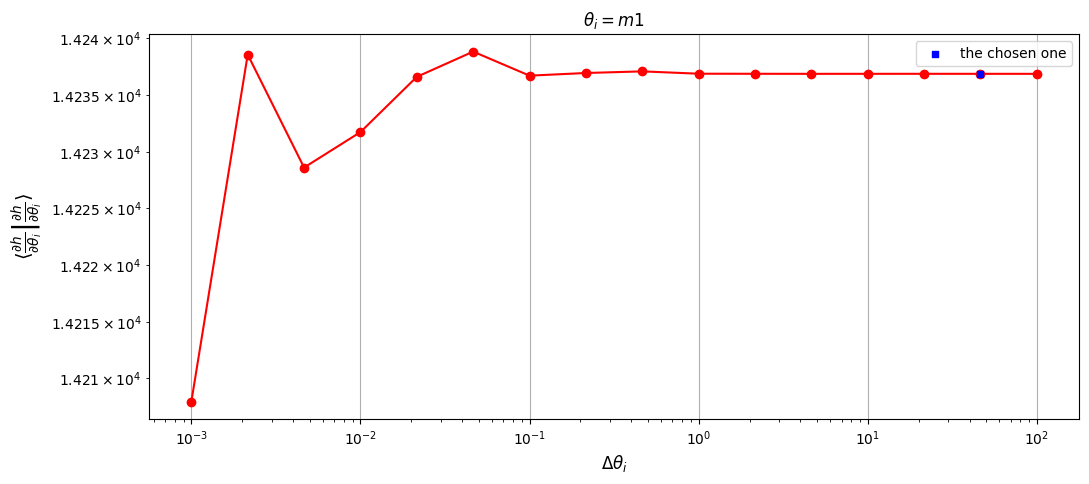

Gamma_ii for m2: 9078226646498.605
Gamma_ii for m2: 9078228935196.88
Gamma_ii for m2: 9078222236077.695
Gamma_ii for m2: 9078228391506.404
Gamma_ii for m2: 9078182580238.053
Gamma_ii for m2: 9078262068067.898
Gamma_ii for m2: 9078041218015.85
Gamma_ii for m2: 9078382085115.816
Gamma_ii for m2: 9078496746619.906
Gamma_ii for m2: 9077866834721.258
Gamma_ii for m2: 9082968329080.568
Gamma_ii for m2: 9077425166558.617
Gamma_ii for m2: 9065877281998.305
Gamma_ii for m2: 9058925856773.604
Gamma_ii for m2: 9086592660181.121
Gamma_ii for m2: 9002710148543.027
[np.float64(2.521084554848792e-07), np.float64(7.379329356935057e-07), np.float64(6.780429444519591e-07), np.float64(5.046303921149074e-06), np.float64(8.755842169978279e-06), np.float64(2.4327941099291286e-05), np.float64(3.754711982498017e-05), np.float64(1.2630009933366376e-05), np.float64(6.938985888613548e-05), np.float64(0.000561654976047566), np.float64(0.0006106536182057742), np.float64(0.0012737746388033072), np.float64(0.0007673

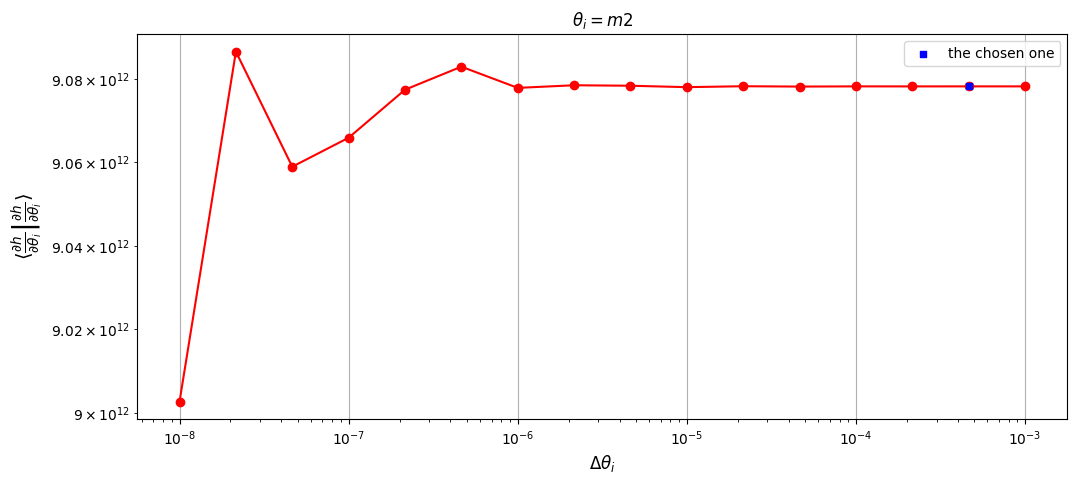

Gamma_ii for a: 1161814539495305.0
Gamma_ii for a: 1161814345031876.5
Gamma_ii for a: 1161815015937086.0
Gamma_ii for a: 1161813037636557.2
Gamma_ii for a: 1161813000623489.5
Gamma_ii for a: 1161811623837943.5
Gamma_ii for a: 1161794658525513.0
Gamma_ii for a: 1161859871614525.0
Gamma_ii for a: 1161895127622462.5
Gamma_ii for a: 1161690186914671.0
Gamma_ii for a: 1162341061087062.2
Gamma_ii for a: 1163167973294116.0
Gamma_ii for a: 1160963521201496.2
Gamma_ii for a: 1162539966786887.0
Gamma_ii for a: 1161119354994300.8
Gamma_ii for a: 1190334224858539.2
[np.float64(1.6737909058496309e-07), np.float64(5.774630214766741e-07), np.float64(1.702770122785332e-06), np.float64(3.1858025112592865e-08), np.float64(1.185033371805929e-06), np.float64(1.4602677251099999e-05), np.float64(5.612818774899217e-05), np.float64(3.034353712253093e-05), np.float64(0.0001764159757050211), np.float64(0.0005599683209870686), np.float64(0.0007109138370719728), np.float64(0.0018988125400687301), np.float64(0.001

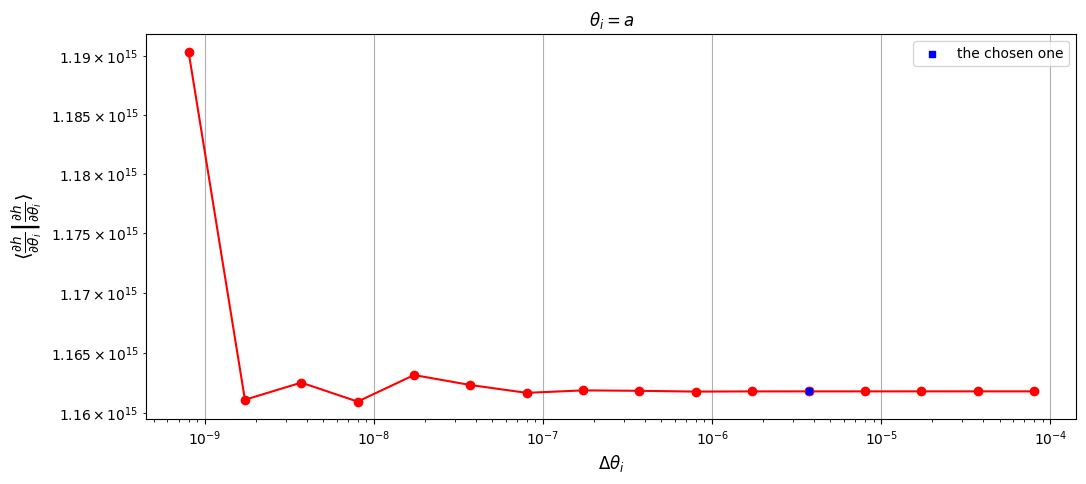

Gamma_ii for p0: 750450324861249.4
Gamma_ii for p0: 750450326897303.6
Gamma_ii for p0: 750450356159338.9
Gamma_ii for p0: 750450096987577.2
Gamma_ii for p0: 750450598164074.4
Gamma_ii for p0: 750450411536453.4
Gamma_ii for p0: 750448552206513.6
Gamma_ii for p0: 750457307657675.9
Gamma_ii for p0: 750443307636513.4
Gamma_ii for p0: 750473984286315.5
Gamma_ii for p0: 750419120602283.4
Gamma_ii for p0: 750404901554763.6
Gamma_ii for p0: 750316216138147.1
Gamma_ii for p0: 750849209500029.2
Gamma_ii for p0: 750025535099371.4
Gamma_ii for p0: 753720774003571.1
[np.float64(2.7131099514846725e-09), np.float64(3.899263290347078e-08), np.float64(3.453550911184575e-07), np.float64(6.678340964096688e-07), np.float64(2.486874790539501e-07), np.float64(2.4776247942421732e-06), np.float64(1.1666821114151685e-05), np.float64(1.8655667949911395e-05), np.float64(4.0876366728818496e-05), np.float64(7.311072242947598e-05), np.float64(1.8948500323344853e-05), np.float64(0.00011819738759340818), np.float64(0

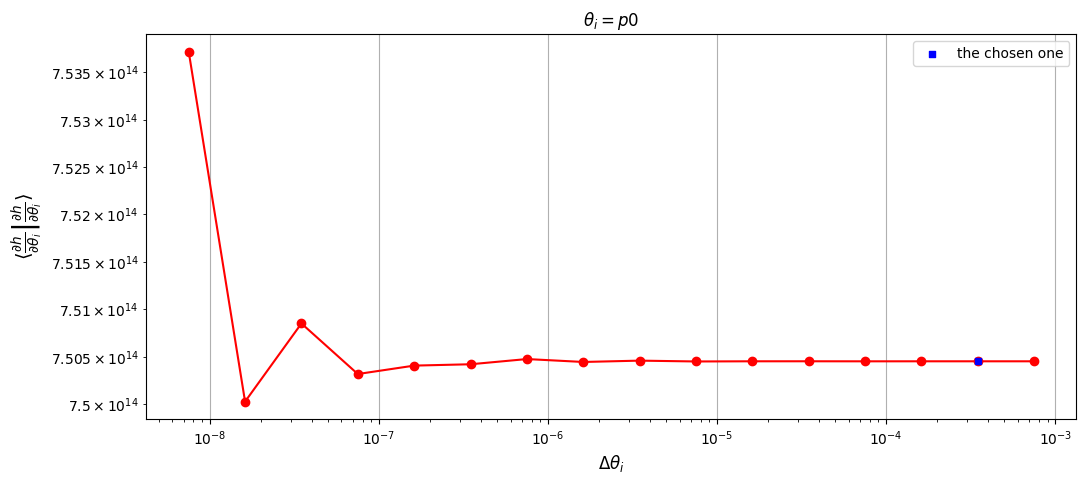

Gamma_ii for e0: 2442978374252414.0
Gamma_ii for e0: 2442976436468850.5
Gamma_ii for e0: 2442980217259338.5
Gamma_ii for e0: 2442975950612235.0
Gamma_ii for e0: 2442991159638433.0
Gamma_ii for e0: 2442978101311712.5
Gamma_ii for e0: 2443086281682662.0
Gamma_ii for e0: 2443172187224901.0
Gamma_ii for e0: 2442710552853343.5
Gamma_ii for e0: 2443373236009469.5
Gamma_ii for e0: 2443134430611557.5
Gamma_ii for e0: 2441120351309122.0
Gamma_ii for e0: 2448686671051042.5
Gamma_ii for e0: 2431985297172358.5
Gamma_ii for e0: 2480305830210499.5
Gamma_ii for e0: 2482049176544560.5
[np.float64(7.932059984585561e-07), np.float64(1.5476140417712782e-06), np.float64(1.7464957452531346e-06), np.float64(6.225575617822114e-06), np.float64(5.345249191340917e-06), np.float64(4.428020891468122e-05), np.float64(3.5161476824348016e-05), np.float64(0.00018898447506122344), np.float64(0.0002712165077195892), np.float64(9.774550058312715e-05), np.float64(0.000825063500599383), np.float64(0.003089950148122802), n

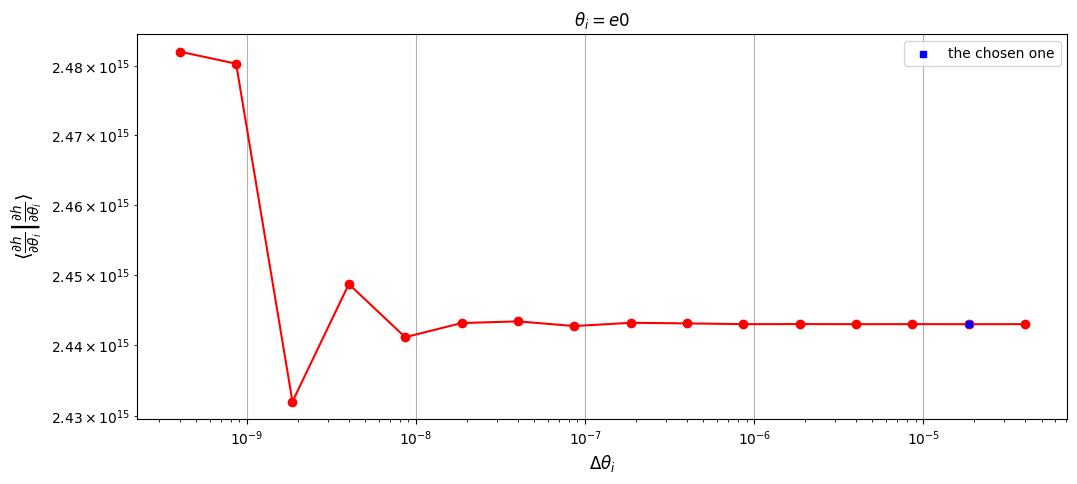

Gamma_ii for qS: 36775.8170476471
Gamma_ii for qS: 36775.81710908575
Gamma_ii for qS: 36775.81710922063
Gamma_ii for qS: 36775.817109221
Gamma_ii for qS: 36775.817109220276
Gamma_ii for qS: 36775.81710922131
Gamma_ii for qS: 36775.817109220174
Gamma_ii for qS: 36775.8171092122
Gamma_ii for qS: 36775.81710922998
Gamma_ii for qS: 36775.81710924746
Gamma_ii for qS: 36775.81710914047
Gamma_ii for qS: 36775.81710910033
Gamma_ii for qS: 36775.81710925361
Gamma_ii for qS: 36775.817109590855
Gamma_ii for qS: 36775.81711044002
Gamma_ii for qS: 36775.81711057546
[np.float64(1.6706264220645492e-09), np.float64(3.667673837161706e-12), np.float64(1.0090158900380036e-14), np.float64(1.9784625294863208e-14), np.float64(2.8094167918704966e-14), np.float64(3.086401545998669e-14), np.float64(2.1683949323174837e-13), np.float64(4.835362422063291e-13), np.float64(4.75226699582263e-13), np.float64(2.909131303362999e-12), np.float64(1.0915177775211632e-12), np.float64(4.167829164612106e-12), np.float64(9.17

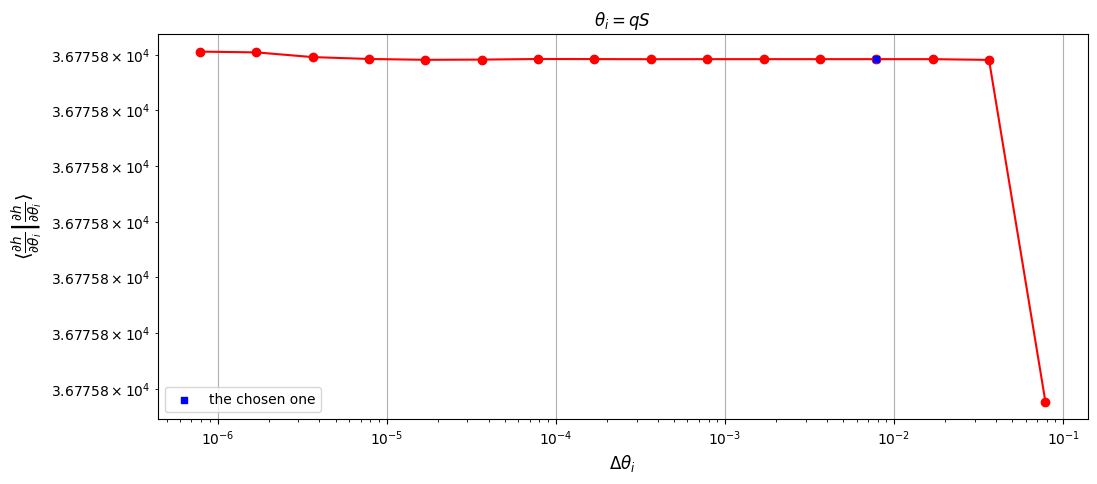

Gamma_ii for phiS: 709755.3295815336
Gamma_ii for phiS: 709755.3295583776
Gamma_ii for phiS: 709755.3295583264
Gamma_ii for phiS: 709755.3295583263
Gamma_ii for phiS: 709755.3295583263
Gamma_ii for phiS: 709755.3295583262
Gamma_ii for phiS: 709755.3295583263
Gamma_ii for phiS: 709755.3295583264
Gamma_ii for phiS: 709755.3295583263
Gamma_ii for phiS: 709755.3295583264
Gamma_ii for phiS: 709755.3295583274
Gamma_ii for phiS: 709755.3295583258
Gamma_ii for phiS: 709755.3295583238
Gamma_ii for phiS: 709755.3295583215
Gamma_ii for phiS: 709755.3295582832
Gamma_ii for phiS: 709755.3295583308
[np.float64(3.2625241219900364e-11), np.float64(7.216957657186839e-14), np.float64(1.6402176493606455e-16), np.float64(0.0), np.float64(1.6402176493606458e-16), np.float64(1.6402176493606455e-16), np.float64(1.640217649360645e-16), np.float64(1.6402176493606455e-16), np.float64(1.640217649360645e-16), np.float64(1.4761958844245784e-15), np.float64(2.296304709104905e-15), np.float64(2.7883700039131066e-15)

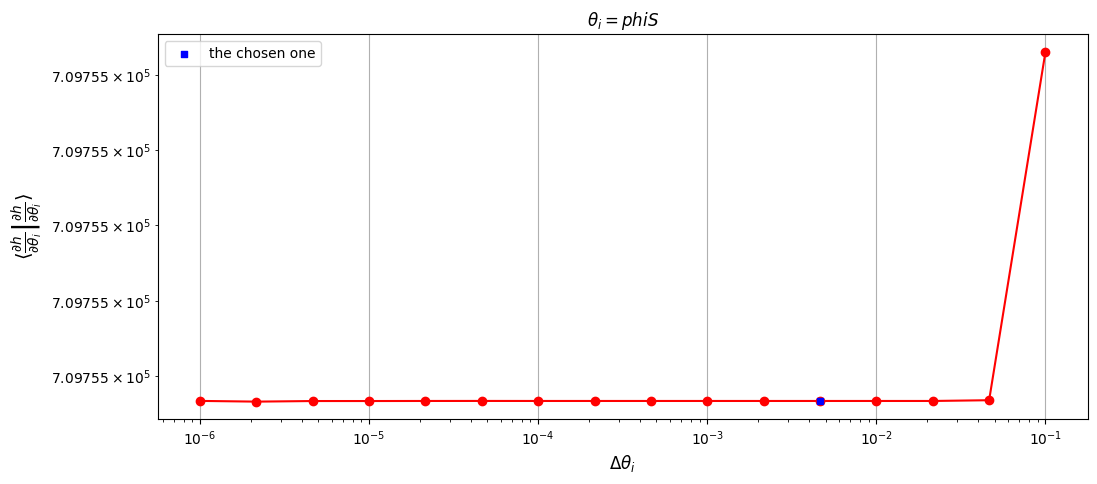

Gamma_ii for devCp: 4900.279524102492
Gamma_ii for devCp: 4972.259291789495
Gamma_ii for devCp: 4957.213679483613
Gamma_ii for devCp: 3677.3788813131778
Gamma_ii for devCp: 3515.5815097480327
Gamma_ii for devCp: 3374.6568671686196
Gamma_ii for devCp: 122684.00489555273
Gamma_ii for devCp: 337663.26962595497
Gamma_ii for devCp: 1435739.128266105
Gamma_ii for devCp: 19038309.637801874
Gamma_ii for devCp: 12200815.010777984
Gamma_ii for devCp: 7714061.376546762
Gamma_ii for devCp: 211536085.92673594
Gamma_ii for devCp: 1666771402.71192
Gamma_ii for devCp: 10299684482.78251
Gamma_ii for devCp: 38933111659.71777
[np.float64(0.014476269933440616), np.float64(0.003035094566964348), np.float64(0.34802908252777354), np.float64(0.04602293279689635), np.float64(0.04175969531908312), np.float64(0.9724930982645892), np.float64(0.6366676037004102), np.float64(0.7648157224538835), np.float64(0.9245868380344364), np.float64(0.5604129413472599), np.float64(0.5816331262118813), np.float64(0.963533118509

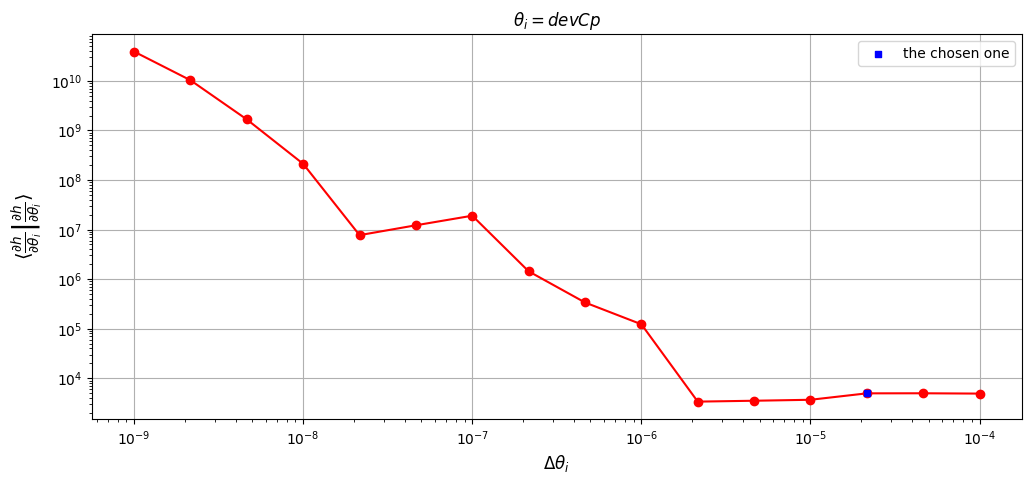

Gamma_ii for devCe: 33143.77433572722
Gamma_ii for devCe: 33153.690572347274
Gamma_ii for devCe: 30133.516654362295
Gamma_ii for devCe: 30594.850665189235
Gamma_ii for devCe: 64590.97662151758
Gamma_ii for devCe: 127741.76288235992
Gamma_ii for devCe: 8703.319673677206
Gamma_ii for devCe: 246907.1863879594
Gamma_ii for devCe: 2255687.336325533
Gamma_ii for devCe: 2981062.1957866508
Gamma_ii for devCe: 24264907.782353982
Gamma_ii for devCe: 254506574.1337507
Gamma_ii for devCe: 82515936.15861422
Gamma_ii for devCe: 840548786.8572359
Gamma_ii for devCe: 1759026942.2091987
Gamma_ii for devCe: 56716762980.074875
[np.float64(0.00029909902785680545), np.float64(0.10022640080900622), np.float64(0.015078812309806282), np.float64(0.5263293378506217), np.float64(0.4943628836483119), np.float64(13.677360785529808), np.float64(0.9647506425349569), np.float64(0.8905401549178504), np.float64(0.2433276502873177), np.float64(0.8771451256882768), np.float64(0.9046590137604774), np.float64(2.08433238452

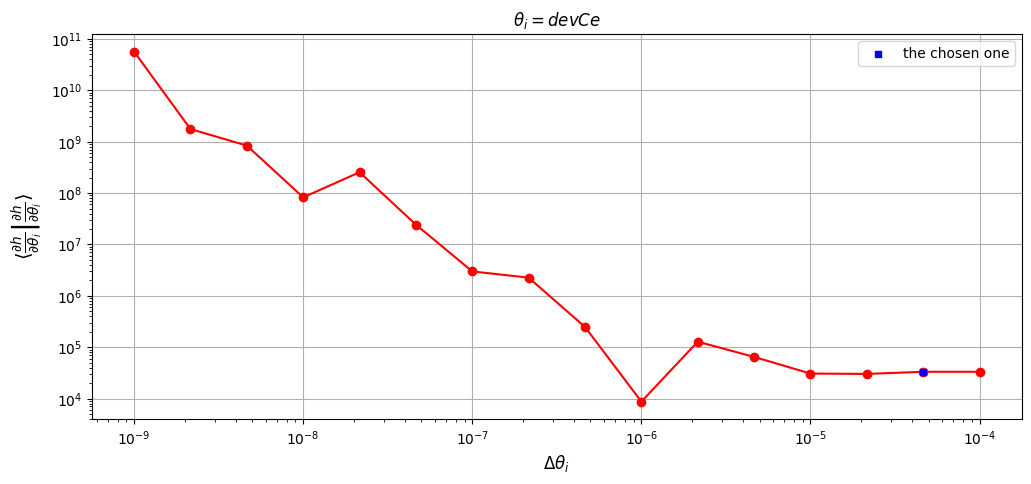

stable deltas: {'m1': 46.4158883361278, 'm2': 0.00046415888336127773, 'a': 3.713271066890227e-06, 'p0': 0.0003481191625209583, 'e0': 1.8566355334451135e-05, 'qS': 0.007853981633974485, 'phiS': 0.004641588833612782, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'devCp': 2.1544346900318823e-05, 'devCe': 4.641588833612782e-05}
Time taken to compute stable deltas is 65.16321206092834 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 5.276787996292114 seconds


In [37]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','devCp','devCe']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [17]:
Fisher=Fisher[-1]

In [18]:
from stableemrifisher.utils import fishinv
J = np.eye(len(Fisher))
J[0,0] = m1
Fisher_lnM = J.T @ Fisher @ J
Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)
Fisher_inv = J.T @ Fisher_lnM_inv @ J
pd.DataFrame(np.matmul(Fisher_lnM,Fisher_lnM_inv))

,0,1,2,3,4,5,6,7,8,9,10
0,1.000000e+00,7.147134e-09,-5.249912e-10,1.551711e-08,8.874403e-10,2.145716e-09,-2.300041e-09,4.297282e-07,-5.319077e-07,1.722155e-06,2.887841e-05
1,-3.783185e-11,1.000000e+00,-1.558325e-11,-1.357348e-10,-2.394885e-11,-1.267490e-10,1.382957e-11,-2.328428e-08,2.144939e-08,-2.882549e-07,-3.059896e-06
2,1.139967e-10,4.707970e-09,1.000000e+00,4.059710e-09,2.481582e-10,5.394299e-10,-4.371581e-10,-2.631149e-08,-2.371500e-07,2.853312e-06,2.346414e-05
3,3.049223e-10,3.451792e-09,-3.239394e-10,1.000000e+00,7.204938e-11,6.560367e-11,-2.225661e-10,1.310173e-07,-1.986344e-07,3.850882e-06,2.548710e-05
4,2.364963e-09,1.401776e-08,-2.256852e-10,8.021331e-10,1.000000e+00,7.180816e-11,-1.436300e-10,-7.166792e-08,-7.722926e-08,1.114997e-05,1.881282e-05
5,1.454889e-15,-3.917214e-15,-3.283037e-16,-6.803941e-15,6.865607e-16,1.000000e+00,3.380157e-15,6.278984e-13,1.288782e-12,2.771872e-12,-4.602229e-11
6,1.711821e-14,2.010055e-13,2.755548e-15,2.769404e-15,-6.341067e-15,3.580712e-15,1.000000e+00,-5.869383e-14,-1.539653e-12,1.069692e-10,4.109181e-11
7,-2.464375e-15,-8.126224e-15,-2.164071e-15,-2.852502e-14,-1.146479e-15,-4.424187e-15,-6.958459e-15,1.000000e+00,1.021355e-12,-9.941754e-12,2.778552e-11
8,-2.318294e-16,-3.868665e-15,-1.906578e-16,-6.341521e-15,-4.046577e-16,2.326457e-15,-2.832182e-15,-4.177992e-13,1.000000e+00,-9.058313e-12,-3.094833e-11
9,3.649798e-15,1.614461e-14,-8.573455e-17,-4.712637e-16,-5.180307e-16,-4.340280e-15,-3.506366e-15,-3.763781e-13,-2.462700e-13,1.000000e+00,-5.895607e-12


In [19]:
print(np.linalg.cond(Fisher_lnM))
np.sum(np.matmul(Fisher_lnM,Fisher_lnM_inv))


1.463771165933008e+16


np.float64(11.00011233925699)

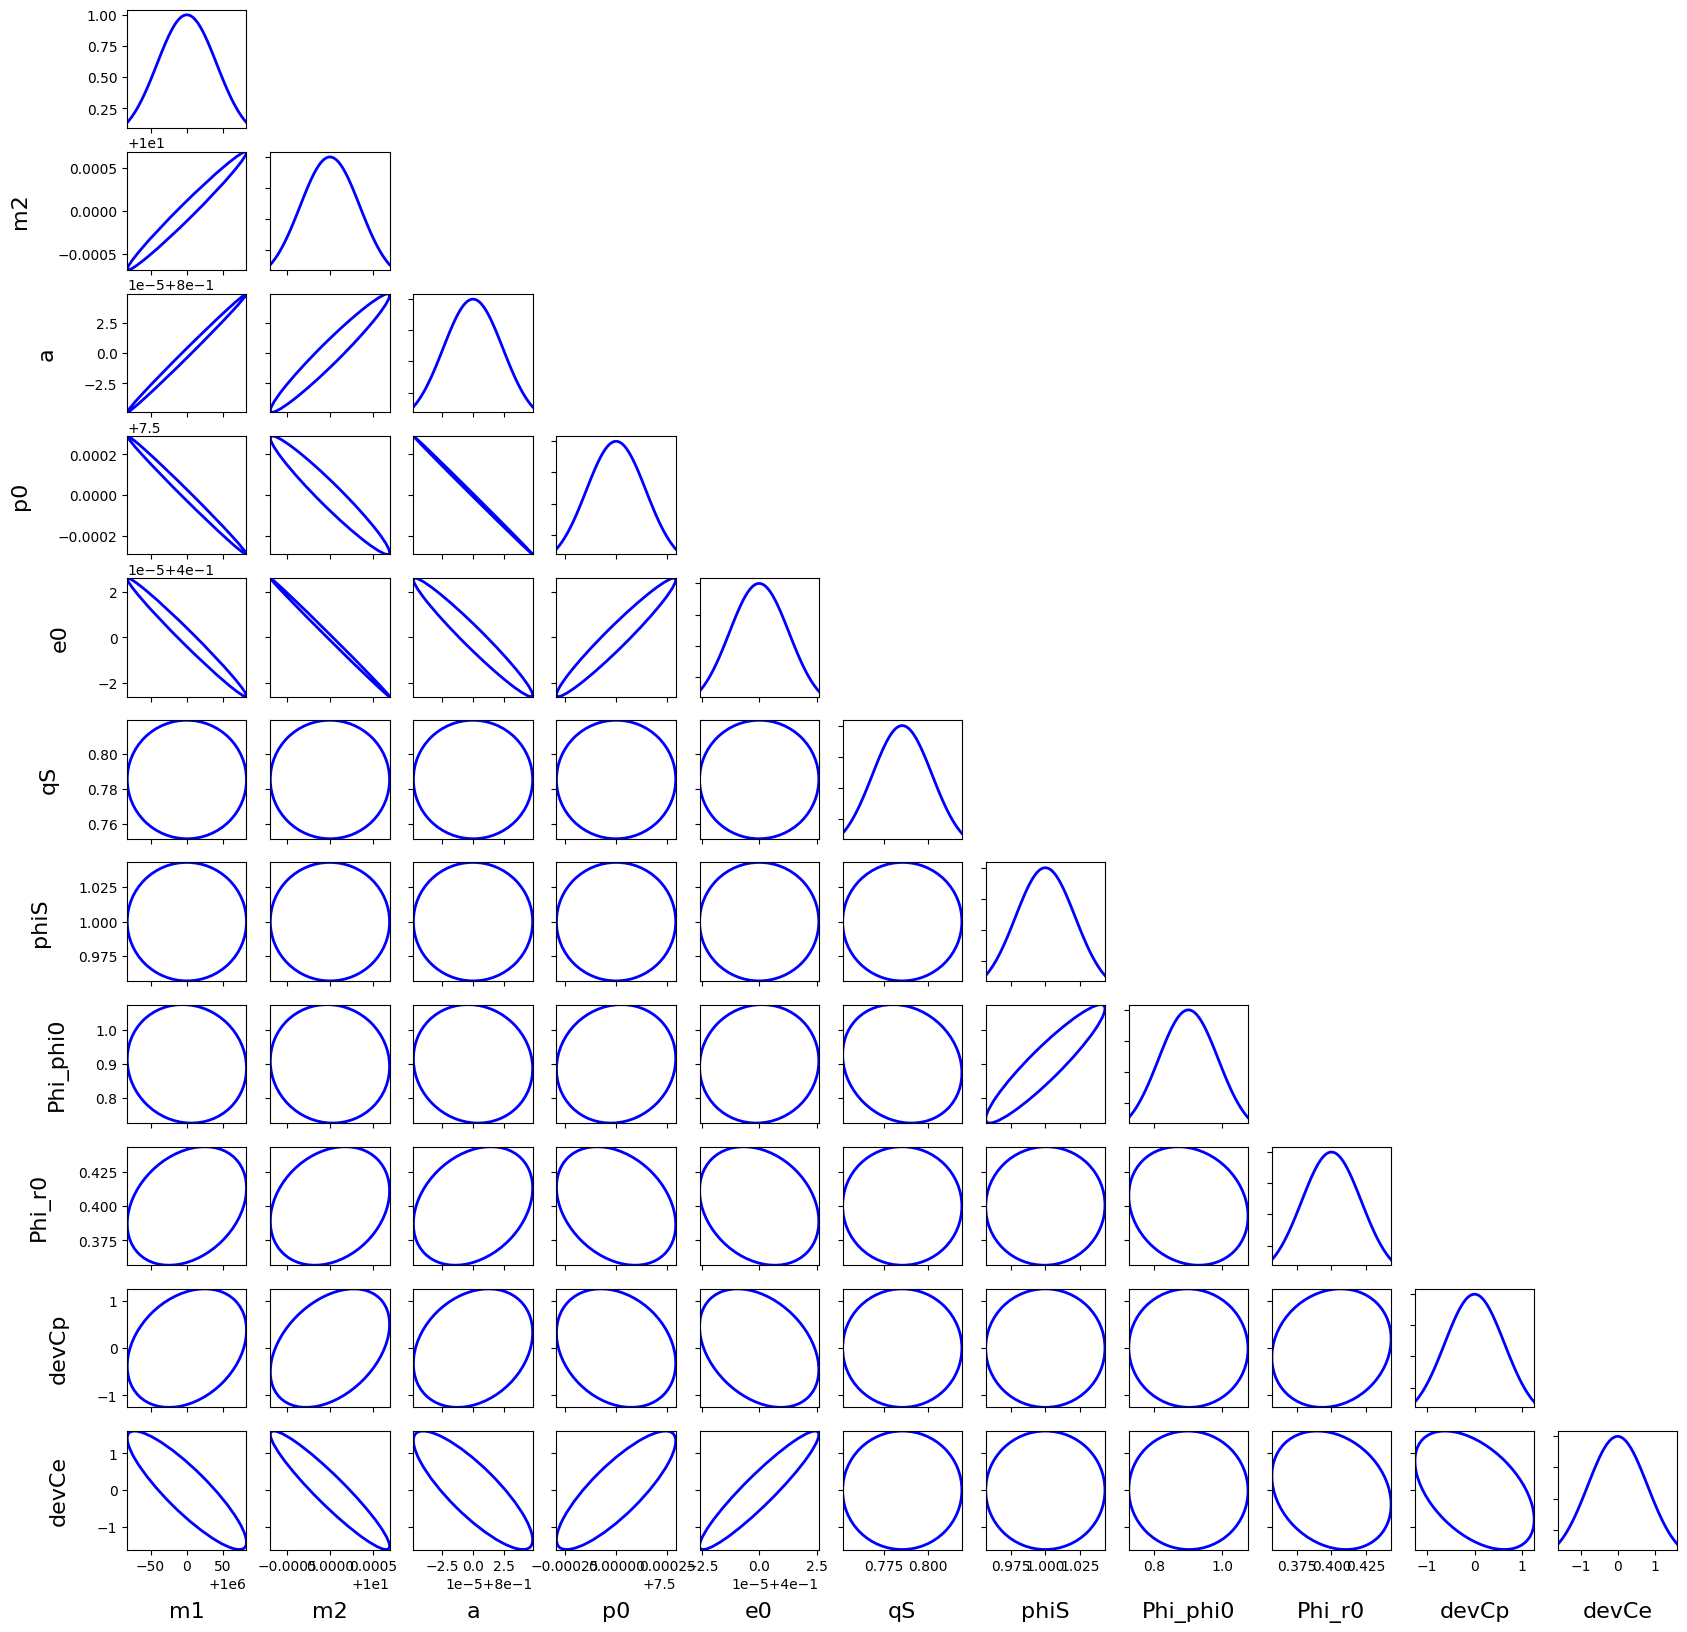

In [24]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = [m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_C_p, dev_C_e]
param_names = ["m1",'m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','devCp','devCe']
wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = pars_list[i]
    
covariance = Fisher_inv

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)

Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.8, 7.5, 0.4, 1.0, 0.5, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.9, True, False, False, True, 0.0, 0.0)
Waveform Generated. SNR: 109.44068348468616
calculating stable deltas...
Gamma_ii for m1: 14236.87489695659
Gamma_ii for m1: 14236.875843331984
Gamma_ii for m1: 14236.877620007497
Gamma_ii for m1: 14236.876125621317
Gamma_ii for m1: 14236.875003108526
Gamma_ii for m1: 14236.879430297375
Gamma_ii for m1: 14236.88610519955
Gamma_ii for m1: 14237.092661044006
Gamma_ii for m1: 14236.948961239326
Gamma_ii for m1: 14236.71429135059
Gamma_ii for m1: 14238.83793388457
Gamma_ii for m1: 14236.609330277732
Gamma_ii for m1: 14231.728642002687
Gamma_ii for m1: 14228.596613296793
Gamma_ii for m1: 14238.575494227774
Gamma_ii for m1: 14207.941549380024
[np.float64(6.647353004023656e-08), np.float64(1.2479390221870082e-07), np.float64(1.0496

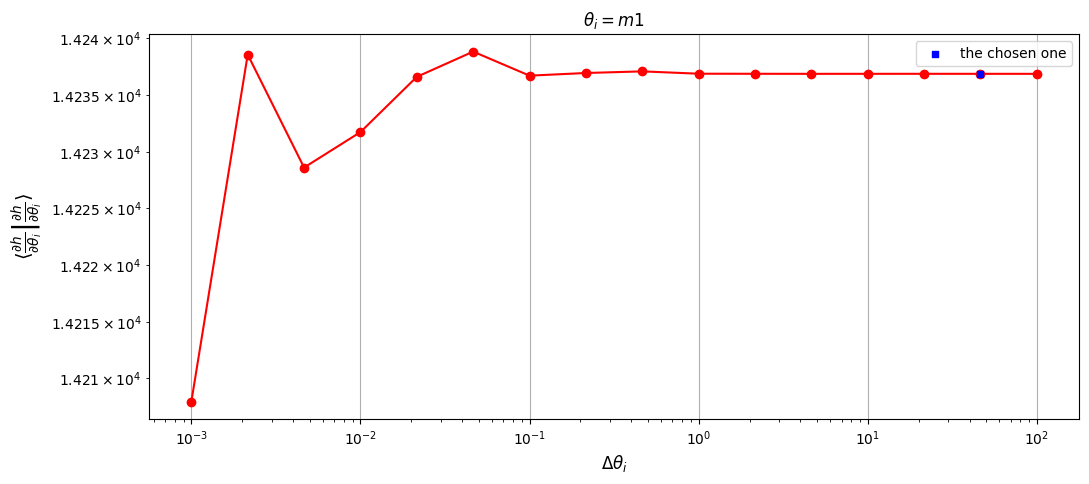

Gamma_ii for m2: 9078226646498.605
Gamma_ii for m2: 9078228935196.88
Gamma_ii for m2: 9078222236077.695
Gamma_ii for m2: 9078228391506.404
Gamma_ii for m2: 9078182580238.053
Gamma_ii for m2: 9078262068067.898
Gamma_ii for m2: 9078041218015.85
Gamma_ii for m2: 9078382085115.816
Gamma_ii for m2: 9078496746619.906
Gamma_ii for m2: 9077866834721.258
Gamma_ii for m2: 9082968329080.568
Gamma_ii for m2: 9077425166558.617
Gamma_ii for m2: 9065877281998.305
Gamma_ii for m2: 9058925856773.604
Gamma_ii for m2: 9086592660181.121
Gamma_ii for m2: 9002710148543.027
[np.float64(2.521084554848792e-07), np.float64(7.379329356935057e-07), np.float64(6.780429444519591e-07), np.float64(5.046303921149074e-06), np.float64(8.755842169978279e-06), np.float64(2.4327941099291286e-05), np.float64(3.754711982498017e-05), np.float64(1.2630009933366376e-05), np.float64(6.938985888613548e-05), np.float64(0.000561654976047566), np.float64(0.0006106536182057742), np.float64(0.0012737746388033072), np.float64(0.0007673

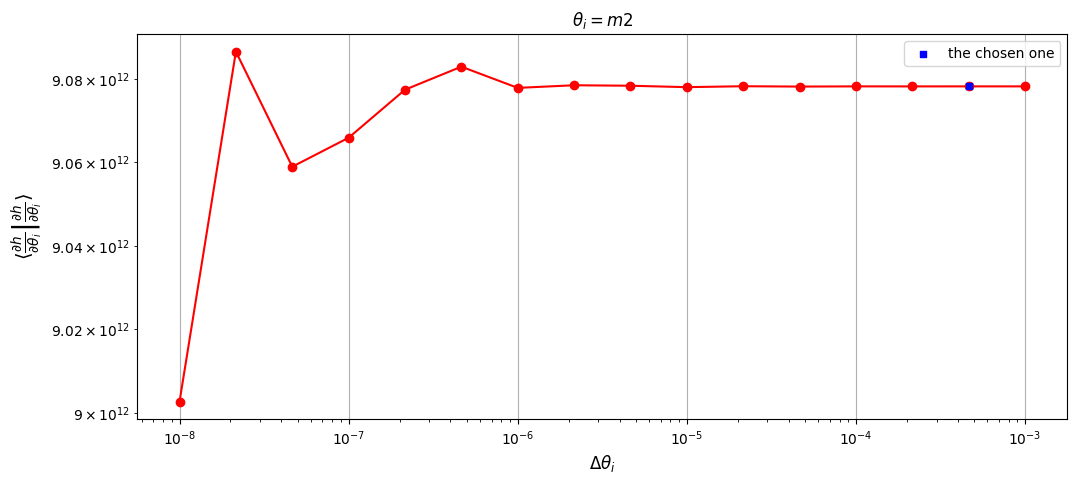

Gamma_ii for a: 1161814539495305.0
Gamma_ii for a: 1161814345031876.5
Gamma_ii for a: 1161815015937086.0
Gamma_ii for a: 1161813037636557.2
Gamma_ii for a: 1161813000623489.5
Gamma_ii for a: 1161811623837943.5
Gamma_ii for a: 1161794658525513.0
Gamma_ii for a: 1161859871614525.0
Gamma_ii for a: 1161895127622462.5
Gamma_ii for a: 1161690186914671.0
Gamma_ii for a: 1162341061087062.2
Gamma_ii for a: 1163167973294116.0
Gamma_ii for a: 1160963521201496.2
Gamma_ii for a: 1162539966786887.0
Gamma_ii for a: 1161119354994300.8
Gamma_ii for a: 1190334224858539.2
[np.float64(1.6737909058496309e-07), np.float64(5.774630214766741e-07), np.float64(1.702770122785332e-06), np.float64(3.1858025112592865e-08), np.float64(1.185033371805929e-06), np.float64(1.4602677251099999e-05), np.float64(5.612818774899217e-05), np.float64(3.034353712253093e-05), np.float64(0.0001764159757050211), np.float64(0.0005599683209870686), np.float64(0.0007109138370719728), np.float64(0.0018988125400687301), np.float64(0.001

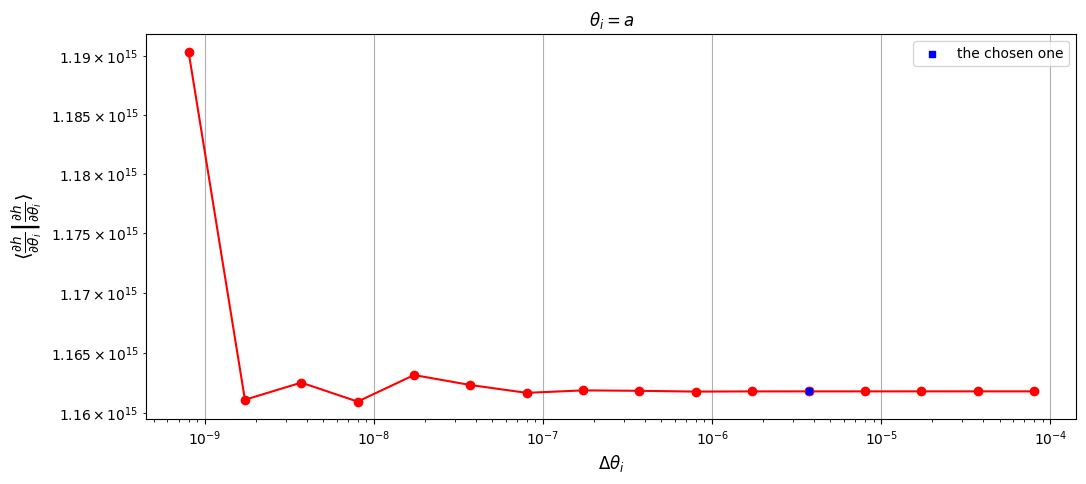

Gamma_ii for p0: 750450324861249.4
Gamma_ii for p0: 750450326897303.6
Gamma_ii for p0: 750450356159338.9
Gamma_ii for p0: 750450096987577.2
Gamma_ii for p0: 750450598164074.4
Gamma_ii for p0: 750450411536453.4
Gamma_ii for p0: 750448552206513.6
Gamma_ii for p0: 750457307657675.9
Gamma_ii for p0: 750443307636513.4
Gamma_ii for p0: 750473984286315.5
Gamma_ii for p0: 750419120602283.4
Gamma_ii for p0: 750404901554763.6
Gamma_ii for p0: 750316216138147.1
Gamma_ii for p0: 750849209500029.2
Gamma_ii for p0: 750025535099371.4
Gamma_ii for p0: 753720774003571.1
[np.float64(2.7131099514846725e-09), np.float64(3.899263290347078e-08), np.float64(3.453550911184575e-07), np.float64(6.678340964096688e-07), np.float64(2.486874790539501e-07), np.float64(2.4776247942421732e-06), np.float64(1.1666821114151685e-05), np.float64(1.8655667949911395e-05), np.float64(4.0876366728818496e-05), np.float64(7.311072242947598e-05), np.float64(1.8948500323344853e-05), np.float64(0.00011819738759340818), np.float64(0

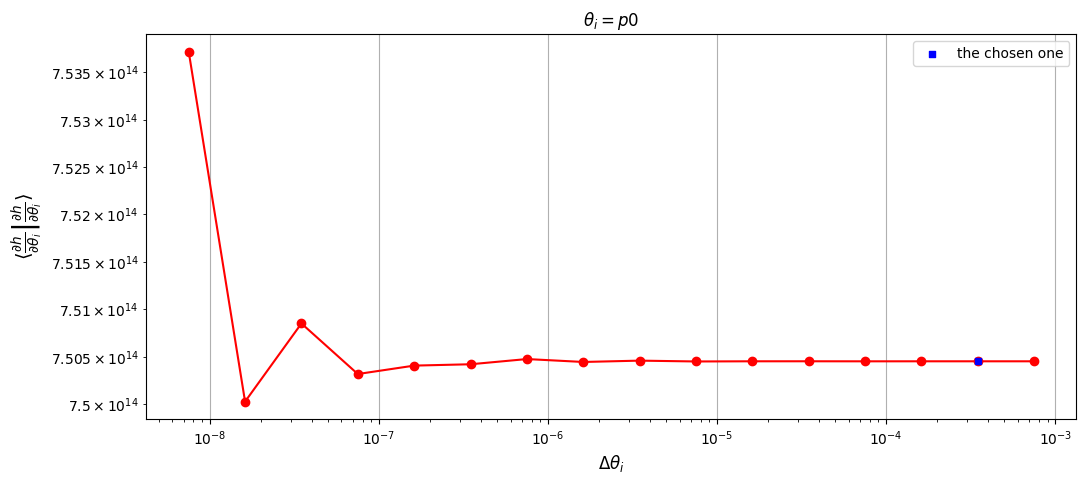

Gamma_ii for e0: 2442978374252414.0
Gamma_ii for e0: 2442976436468850.5
Gamma_ii for e0: 2442980217259338.5
Gamma_ii for e0: 2442975950612235.0
Gamma_ii for e0: 2442991159638433.0
Gamma_ii for e0: 2442978101311712.5
Gamma_ii for e0: 2443086281682662.0
Gamma_ii for e0: 2443172187224901.0
Gamma_ii for e0: 2442710552853343.5
Gamma_ii for e0: 2443373236009469.5
Gamma_ii for e0: 2443134430611557.5
Gamma_ii for e0: 2441120351309122.0
Gamma_ii for e0: 2448686671051042.5
Gamma_ii for e0: 2431985297172358.5
Gamma_ii for e0: 2480305830210499.5
Gamma_ii for e0: 2482049176544560.5
[np.float64(7.932059984585561e-07), np.float64(1.5476140417712782e-06), np.float64(1.7464957452531346e-06), np.float64(6.225575617822114e-06), np.float64(5.345249191340917e-06), np.float64(4.428020891468122e-05), np.float64(3.5161476824348016e-05), np.float64(0.00018898447506122344), np.float64(0.0002712165077195892), np.float64(9.774550058312715e-05), np.float64(0.000825063500599383), np.float64(0.003089950148122802), n

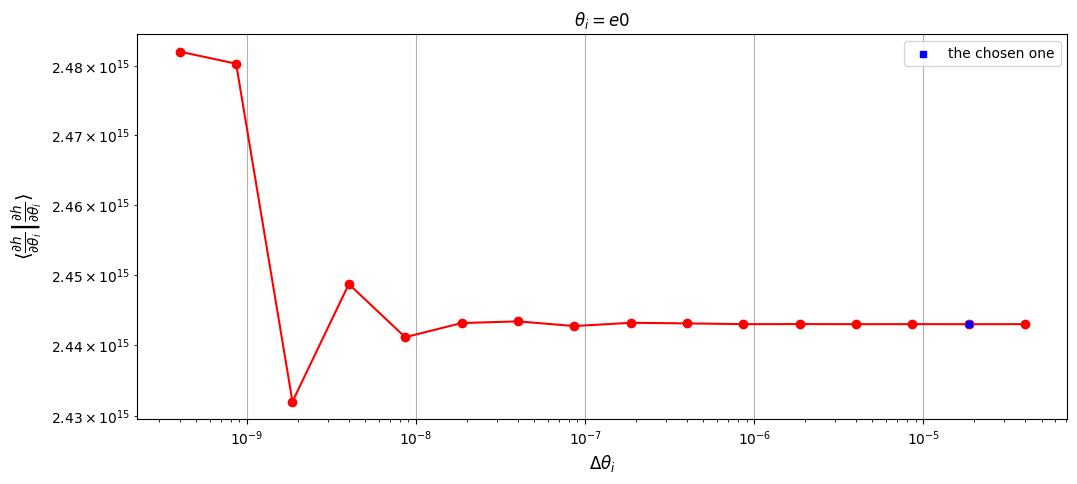

Gamma_ii for qS: 36775.8170476471
Gamma_ii for qS: 36775.81710908575
Gamma_ii for qS: 36775.81710922063
Gamma_ii for qS: 36775.817109221
Gamma_ii for qS: 36775.817109220276
Gamma_ii for qS: 36775.81710922131
Gamma_ii for qS: 36775.817109220174
Gamma_ii for qS: 36775.8171092122
Gamma_ii for qS: 36775.81710922998
Gamma_ii for qS: 36775.81710924746
Gamma_ii for qS: 36775.81710914047
Gamma_ii for qS: 36775.81710910033
Gamma_ii for qS: 36775.81710925361
Gamma_ii for qS: 36775.817109590855
Gamma_ii for qS: 36775.81711044002
Gamma_ii for qS: 36775.81711057546
[np.float64(1.6706264220645492e-09), np.float64(3.667673837161706e-12), np.float64(1.0090158900380036e-14), np.float64(1.9784625294863208e-14), np.float64(2.8094167918704966e-14), np.float64(3.086401545998669e-14), np.float64(2.1683949323174837e-13), np.float64(4.835362422063291e-13), np.float64(4.75226699582263e-13), np.float64(2.909131303362999e-12), np.float64(1.0915177775211632e-12), np.float64(4.167829164612106e-12), np.float64(9.17

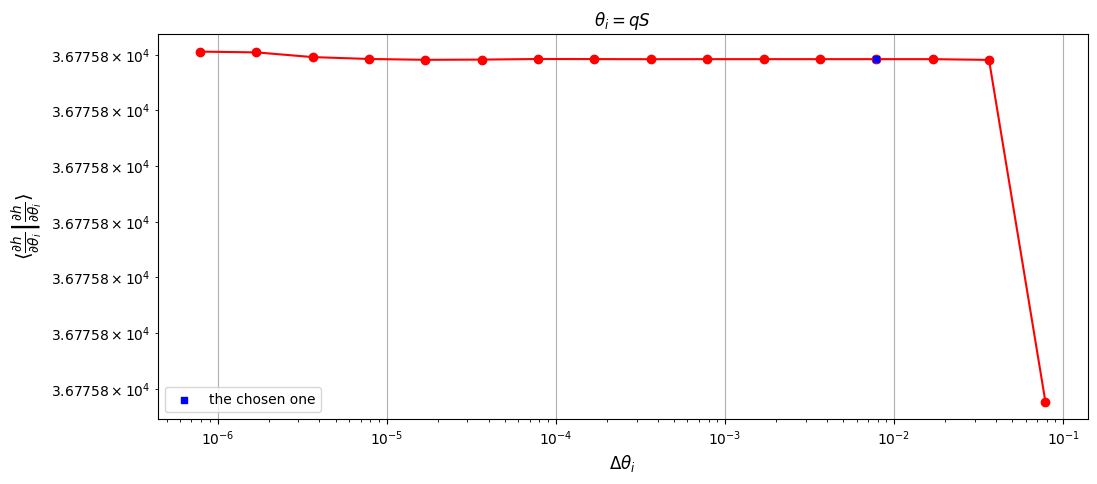

Gamma_ii for phiS: 709755.3295815336
Gamma_ii for phiS: 709755.3295583776
Gamma_ii for phiS: 709755.3295583264
Gamma_ii for phiS: 709755.3295583263
Gamma_ii for phiS: 709755.3295583263
Gamma_ii for phiS: 709755.3295583262
Gamma_ii for phiS: 709755.3295583263
Gamma_ii for phiS: 709755.3295583264
Gamma_ii for phiS: 709755.3295583263
Gamma_ii for phiS: 709755.3295583264
Gamma_ii for phiS: 709755.3295583274
Gamma_ii for phiS: 709755.3295583258
Gamma_ii for phiS: 709755.3295583238
Gamma_ii for phiS: 709755.3295583215
Gamma_ii for phiS: 709755.3295582832
Gamma_ii for phiS: 709755.3295583308
[np.float64(3.2625241219900364e-11), np.float64(7.216957657186839e-14), np.float64(1.6402176493606455e-16), np.float64(0.0), np.float64(1.6402176493606458e-16), np.float64(1.6402176493606455e-16), np.float64(1.640217649360645e-16), np.float64(1.6402176493606455e-16), np.float64(1.640217649360645e-16), np.float64(1.4761958844245784e-15), np.float64(2.296304709104905e-15), np.float64(2.7883700039131066e-15)

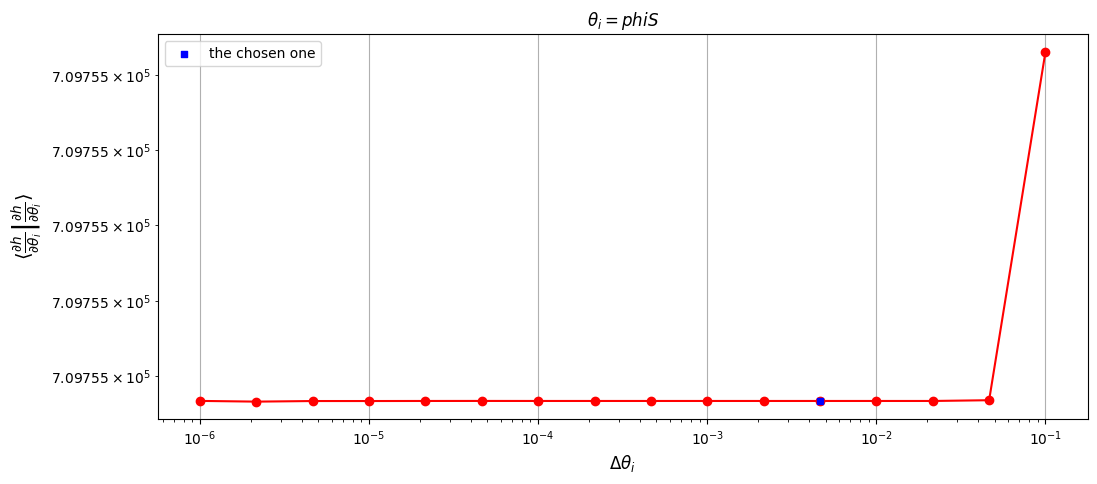

stable deltas: {'m1': 46.4158883361278, 'm2': 0.00046415888336127773, 'a': 3.713271066890227e-06, 'p0': 0.0003481191625209583, 'e0': 1.8566355334451135e-05, 'qS': 0.007853981633974485, 'phiS': 0.004641588833612782, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 47.498753786087036 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.977414131164551 seconds


In [22]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,False,dev_C_p,dev_C_e]
param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher_without_dev = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=False
            )


In [25]:
J = np.eye(len(Fisher_without_dev))
J[0,0] = m1
Fisher_lnM_without_dev = J.T @ Fisher_without_dev @ J
Fisher_lnM_inv_without_dev = np.linalg.inv(Fisher_lnM_without_dev)
Fisher_inv_without_dev = J.T @ Fisher_lnM_inv_without_dev @ J
pd.DataFrame(np.matmul(Fisher_lnM_without_dev ,Fisher_lnM_inv_without_dev))
Cov_without_dev = np.linalg.inv(Fisher_without_dev)

In [27]:
Fisher_inv_reduced = Fisher_inv[:-2,:-2]

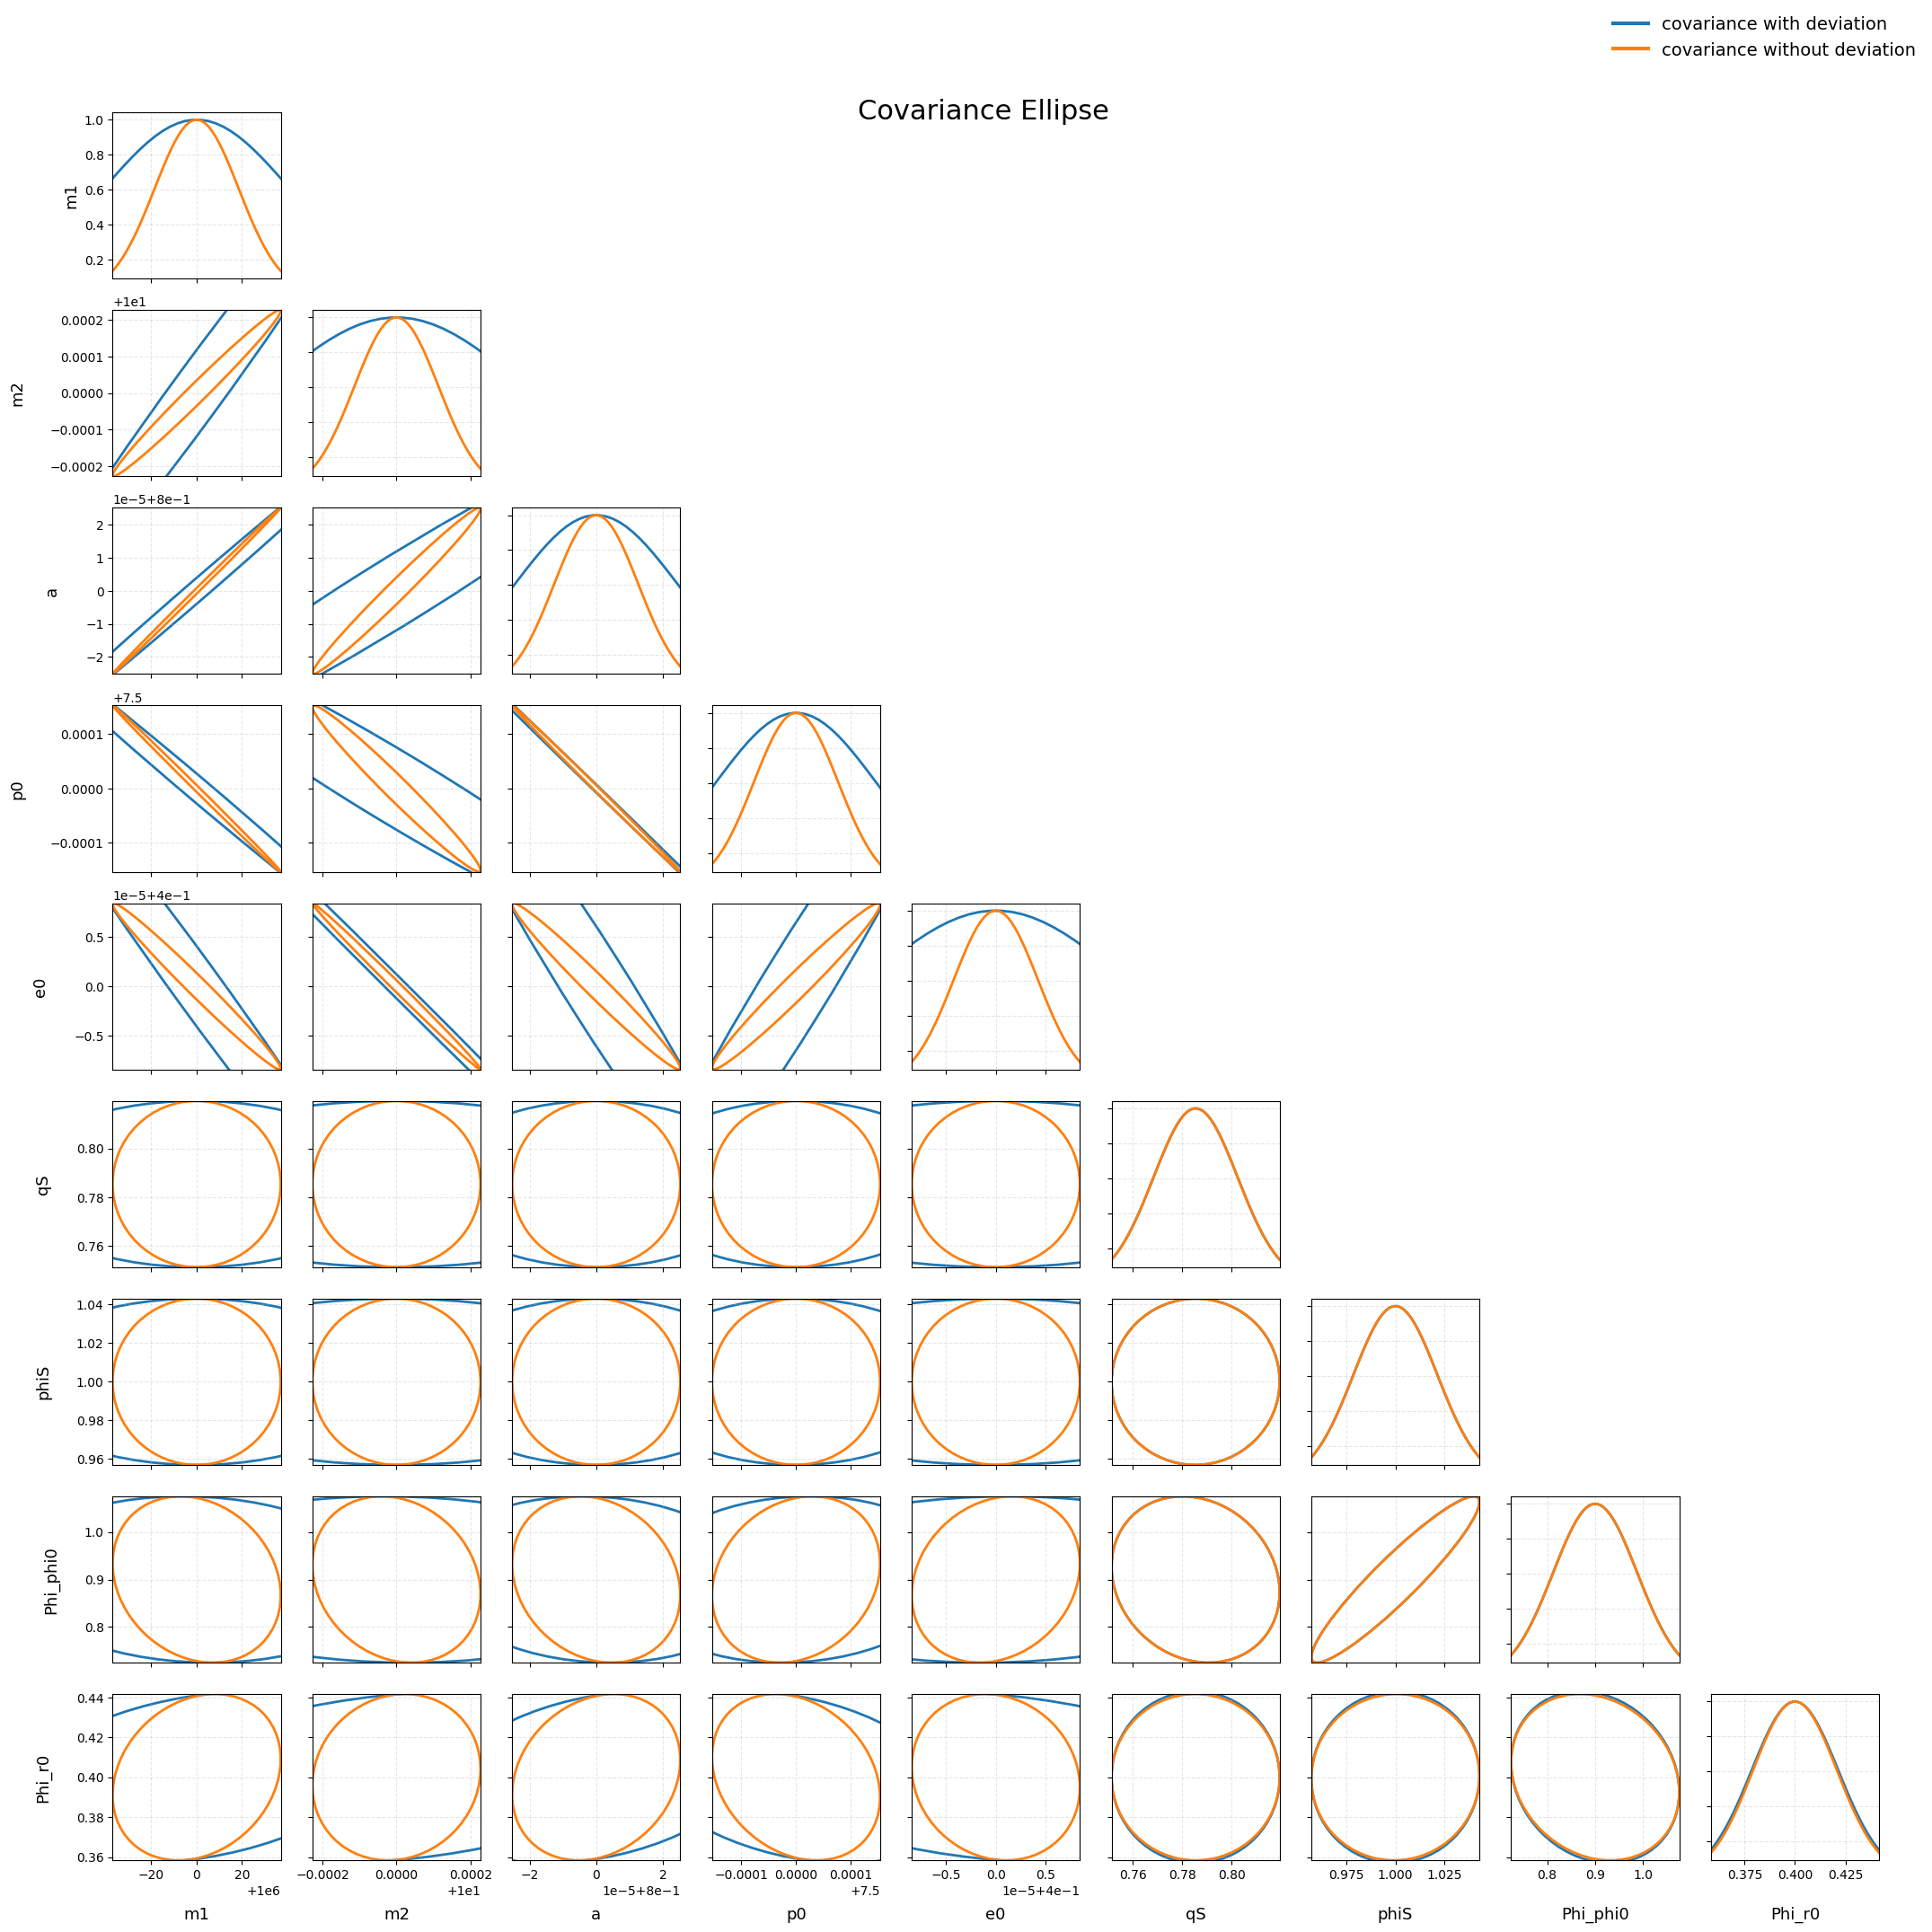

In [29]:


import matplotlib.pyplot as plt
from stableemrifisher.plot import CovEllipsePlot
dev_C_p, dev_C_e=0.0,0.0

# Parameters
pars_list = [m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0]
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']

wave_params = {param_names[i]: pars_list[i] for i in range(len(pars_list))}

ellipse_kwargs_unnorm = dict(facecolor='none', edgecolor='tab:blue', lw=2, label='dev_a (0th order)')
line_kwargs_unnorm = dict(lw=2, color='tab:blue')

ellipse_kwargs_norm = dict(facecolor='none', edgecolor='tab:orange', lw=2, label='dev_b (1st order)')
line_kwargs_norm = dict(lw=2, color='tab:orange')

n_params = len(param_names)
fig, axs = plt.subplots(n_params, n_params, figsize=(22, 22))



fig, axs = CovEllipsePlot(
    Fisher_inv_reduced,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs_unnorm,
    line_kwargs=line_kwargs_unnorm
)

fig, axs = CovEllipsePlot(
    Fisher_inv_without_dev,
    wave_params=wave_params,
    param_names=param_names,
    fig=fig,
    axs=axs,
    ellipse_kwargs=ellipse_kwargs_norm,
    line_kwargs=line_kwargs_norm
)

fig.suptitle("Covariance Ellipse", fontsize=22, y=0.93)

for i in range(n_params):
    for j in range(n_params):
        axs[i, j].grid(True, linestyle='--', alpha=0.3)
        if i < n_params - 1:
            axs[i, j].set_xlabel('')
        if j > 0:
            axs[i, j].set_ylabel('')

for i, name in enumerate(param_names):
    axs[-1, i].set_xlabel(name, fontsize=13)
    axs[i, 0].set_ylabel(name, fontsize=13)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='tab:blue', lw=3, label='covariance with deviation'),
    Line2D([0], [0], color='tab:orange', lw=3, label='covariance without deviation')
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.98, 0.98)
)

plt.tight_layout(rect=[0, 0, 0.96, 0.95])
plt.show()

